<font size=6><b>Lec02.딥러닝 모델 - 분류

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------- ML모델 
from sklearn.ensemble import RandomForestClassifier 
#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#----------------------------------------------------------------------------------- 평가
from sklearn.metrics  import accuracy_score,      f1_score


import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <B>Data Load

In [2]:
from sklearn.datasets import load_iris
X, y = load_iris(as_frame=True , return_X_y=True)
X.columns = ["sl","sw","pl","pw"]
X.head(2)

,sl,sw,pl,pw
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [3]:
y[:10]

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64

# <b> 분류 모델 점수

In [4]:
X80,X20, y80, y20 = train_test_split(X, y, test_size=0.2,random_state=4878, shuffle=True, stratify=y)
model = RandomForestClassifier(random_state=5787)
model.fit(X80, y80)
pred = model.predict(X20)

acc = accuracy_score(y20, pred)
f1  = f1_score(y20, pred, average="macro")
print(f"acc: {acc:.4f}  f1 : {f1:.4f}") 

acc: 0.9667  f1 : 0.9666


# <b> 딥러닝 모델 점수

## sparse_categorical_crossentropy
y : 0 1 2

In [5]:
model = Sequential([
    Dense(units=10, activation="relu" , input_dim=4  ),   #----- input layer
    Dense(units=16, activation="relu"                ),   #----- hidden layer 3
    Dense(units=24, activation="relu"                ),    
    Dense(units=8,  activation="relu"                ),
    Dense(units=3,  activation="softmax"             )    #----- output layer   
 ])

In [6]:
model.compile(loss="sparse_categorical_crossentropy" , optimizer="adam",  metrics=["accuracy"])   #-------------------- l o m

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 861 (3.36 KB)

 Trainable params: 861 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
res = model.fit(X80,y80,     epochs=50 ,   validation_data = (X20,y20)  )
# res
loss,acc = model.evaluate(X20, y20)
print(f"acc : {acc:.4f} , loss:{loss:.4f} " )

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3333 - loss: 1.1511 - val_accuracy: 0.3333 - val_loss: 1.1347
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.1149 - val_accuracy: 0.3333 - val_loss: 1.1019
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.0894 - val_accuracy: 0.3333 - val_loss: 1.0813
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3333 - loss: 1.0735 - val_accuracy: 0.3333 - val_loss: 1.0652
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.0609 - val_accuracy: 0.3333 - val_loss: 1.0505
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3417 - loss: 1.0493 - val_accuracy: 0.3333 - val_loss: 1.0379
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3667 - loss: 1.0371 - val_accuracy: 0.3667 - val_loss: 1.0257
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3750 - loss: 1.0235 - val_accuracy: 0.4333 - val_loss: 1.0122


In [9]:
res.history.keys()  
#res.history['accuracy']

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

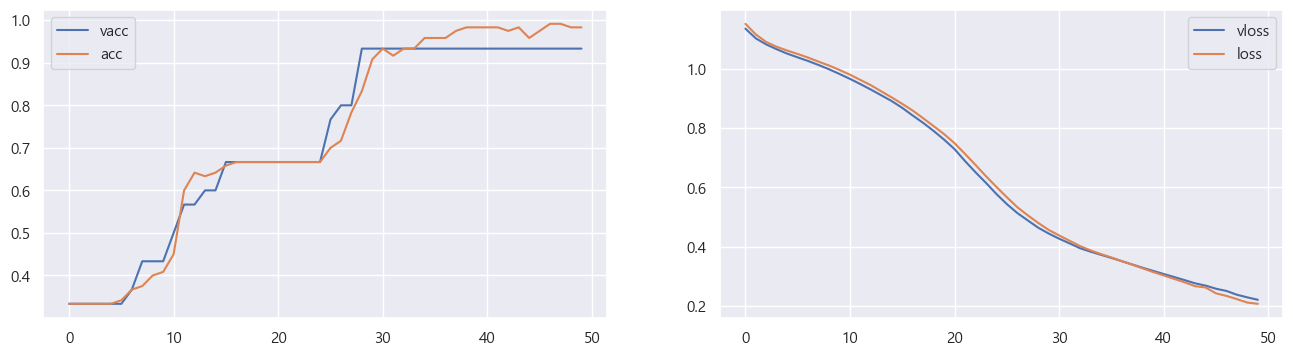

In [10]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(50), vacc , label="vacc")
plt.plot(range(50), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(50),vloss , label="vloss")
plt.plot(range(50),loss  , label="loss")
plt.legend()
plt.show()

##  categorical_crossentropy
* y (원핫인코딩) : 100  010  001
----
* <b>pd.get_dummies(df)
* <b>sklearn.preprocessing.OneHotEncoder()
* <b>tensorflow.keras.utils.to_categorical()

### pd.get_dujmmies(y)

In [11]:
y_oh1 = pd.get_dummies(y,  dtype=int)
y_oh1.head(3)

,0,1,2
0,1,0,0
1,1,0,0
2,1,0,0


### OneHotEncoder

``` python
class sklearn.preprocessing.OneHotEncoder(*, categories='auto', drop=None, sparse_output=True, dtype=<class 'numpy.float64'>, handle_unknown='error', min_frequency=None, max_categories=None, feature_name_combiner='concat')


In [12]:
y2 = np.array(y).reshape(-1,1)
y2[:5]

array([[0],
       [0],
       [0],
       [0],
       [0]])

In [13]:
from sklearn.preprocessing import OneHotEncoder
ohenc = OneHotEncoder(sparse_output=False)
y_oh2 = ohenc.fit_transform(y2)
y_oh2[:5]
# ohenc.fit(y2)                      #------------------2차 [[1,1,0]]
# ohenc.transform(y2)

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

### to_categorical()

In [14]:
from tensorflow.keras.utils import to_categorical

In [15]:
y_oh3 = to_categorical(y)
y_oh3[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [16]:
X80,X20, yoh80, yoh20 = train_test_split(X, y_oh3, test_size=0.2,random_state=4878, shuffle=True, stratify=y)

In [17]:
model = Sequential([
    Dense(units=10, activation="relu" , input_dim=4  ),   #----- input layer
    Dense(units=16, activation="relu"                ),   #----- hidden layer 3
    Dense(units=24, activation="relu"                ),    
    Dense(units=8,  activation="relu"                ),
    Dense(units=3,  activation="softmax"             )    #----- output layer   
 ])
model.compile(loss="categorical_crossentropy" , optimizer="adam",  metrics=["accuracy"])   #-------------------- l o m

In [18]:
res = model.fit(X80,yoh80,     epochs=50 ,   validation_data = (X20,yoh20)  )
# res
loss,acc = model.evaluate(X20, yoh20)
print(f"acc : {acc:.4f} , loss:{loss:.4f} " )

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1250 - loss: 1.2940 - val_accuracy: 0.3333 - val_loss: 1.2004
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2167 - loss: 1.1785 - val_accuracy: 0.2667 - val_loss: 1.1356
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2667 - loss: 1.1089 - val_accuracy: 0.3000 - val_loss: 1.0460
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2667 - loss: 1.0303 - val_accuracy: 0.2333 - val_loss: 0.9561
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2583 - loss: 0.9453 - val_accuracy: 0.5000 - val_loss: 0.8834
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4417 - loss: 0.8834 - val_accuracy: 0.5333 - val_loss: 0.8369
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5083 - loss: 0.8416 - val_accuracy: 0.5333 - val_loss: 0.7975
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5083 - loss: 0.8041 - val_accuracy: 0.5333 - val_loss: 0.7624


# <b><font color=red>모델저장

* HDF5(Hierarchical Data Format version 5) 
* *.h5 : 모델저장포맷
* *.keras : 신규포맷

In [19]:
from tensorflow.keras.saving import load_model, save_model

In [20]:
save_model(model , "lec02_cls_iris.keras")

In [21]:
re_model = load_model("lec02_cls_iris.keras")
re_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,585 (10.10 KB)

 Trainable params: 861 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,724 (6.74 KB)

## 레이어 이름만 출력

In [22]:
for layer in re_model.layers:
    print(layer.name)

dense_5
dense_6
dense_7
dense_8
dense_9


## 레이어 가중치 출력

In [23]:
for w in re_model.get_weights():
    print(w[:1])

[[-0.39144623  0.6073958  -0.37469542 -0.63375497 -0.6532925   0.00243563
   0.19394071  0.42170185  0.09601842  0.22012873]]
[0.]
[[ 0.31431174 -0.11489999  0.21664089  0.18815458 -0.43753898  0.2980693
   0.40064955 -0.28355965  0.12024957  0.3082407  -0.26729292 -0.42286688
  -0.24584098  0.28901118  0.01926139 -0.10375518]]
[-0.05448936]
[[ 0.21107353  0.0758625   0.21236077  0.01898667 -0.2707764   0.36595488
   0.27919668 -0.19629644 -0.05624976 -0.27958855  0.33924204  0.2505493
  -0.12707426  0.03342305  0.19502951 -0.12334207  0.23690537  0.16674368
   0.23186645  0.34196863 -0.01403731 -0.36799884 -0.29276478  0.28265157]]
[-0.03188227]
[[ 0.08188536 -0.38291252  0.14077796  0.38059628  0.29954097  0.05754048
  -0.37874457 -0.12163989]]
[-0.02111236]
[[ 0.35117054 -0.36082608 -0.26743147]]
[0.03717262]


# <b>가중치저장
* .weights.h5 : 가중치 저장 확장자

In [24]:
from tensorflow.keras.saving import load_weights, save_weights

In [25]:
save_weights(re_model,  "lec02_cls_iris.weights.h5")

In [26]:
load_weights(re_model, "lec02_cls_iris.weights.h5")
re_model.get_weights()[:1]

[array([[-0.39144623,  0.6073958 , -0.37469542, -0.63375497, -0.6532925 ,
          0.00243563,  0.19394071,  0.42170185,  0.09601842,  0.22012873],
        [-0.32811755,  0.5552529 , -0.01632768,  0.62959933, -0.11217898,
         -0.0989795 ,  0.5472794 ,  0.48305082, -0.34812567, -0.05269709],
        [ 0.4359076 ,  0.4171897 , -0.47759938, -0.38425463,  0.48605156,
          0.24007347, -0.5439847 ,  0.06518402,  0.66460955, -0.40773165],
        [ 0.00915432, -0.36114123,  0.25158775, -0.48830253, -0.16236249,
          0.19688387, -0.45271704,  0.2532891 ,  0.42611197,  0.6659999 ]],
       dtype=float32)]